/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [04:49:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       290
           1       1.00      1.00      1.00        10

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



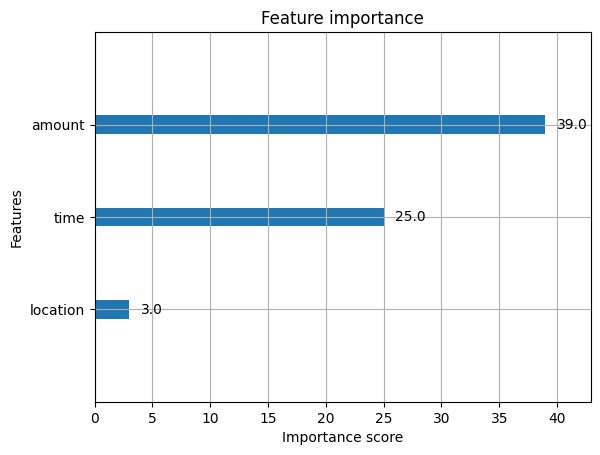

SVM ROC-AUC: 0.9886206896551724


In [1]:
# Step 1: Install missing libraries (run in terminal or notebook)
# pip install imbalanced-learn xgboost matplotlib pandas scikit-learn

# Step 2: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import xgboost as xgb_lib

# Step 3: Synthetic dataset (1000 transactions)
np.random.seed(42)
amount = np.random.exponential(scale=100, size=1000)   # transaction amount
time = np.random.randint(0, 24, 1000)                  # transaction hour
location = np.random.randint(1, 5, 1000)               # location code

# Fraud rule: high amount at odd hours → fraud
fraud = ((amount > 200) & (time < 6)).astype(int)

data = pd.DataFrame({
    'amount': amount,
    'time': time,
    'location': location,
    'fraud': fraud
})

# Step 4: Features and target
X = data[['amount','time','location']]
y = data['fraud']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Handle imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Step 7: Train XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

# Step 8: Predictions
y_pred_prob = xgb.predict_proba(X_test)[:,1]

# Threshold tuning (0.3 instead of 0.5)
threshold = 0.3
y_pred = (y_pred_prob >= threshold).astype(int)

# Step 9: Evaluation
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print(classification_report(y_test, y_pred))

# Step 10: Feature importance
xgb_lib.plot_importance(xgb)
plt.show()

# Step 11: Baseline SVM
svm = SVC(probability=True)
svm.fit(X_train_res, y_train_res)
y_pred_svm_prob = svm.predict_proba(X_test)[:,1]
print("SVM ROC-AUC:", roc_auc_score(y_test, y_pred_svm_prob))
